In [1]:
#einops
from einops import rearrange, einsum
import torch
import matplotlib.pyplot as plt

In [2]:
images = torch.randn(64, 128, 128, 3) # (batch, height, width, channel)
dim_by = torch.linspace(start=0.0, end=1.0, steps=10)

In [3]:
dimmed_images = einsum(
images, dim_by,
"batch height width channel, dim_value -> batch dim_value height width channel"
)

In [14]:
dim_by.shape

torch.Size([10])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.8325374..4.0608993].


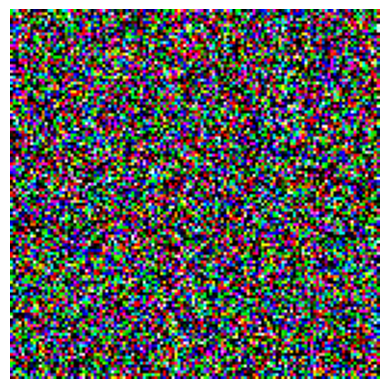

In [7]:
plt.imshow(images[0])
plt.axis("off")
plt.show()

In [10]:
dimmed_images[0,0].shape

torch.Size([128, 128, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.851675..0.9024221].


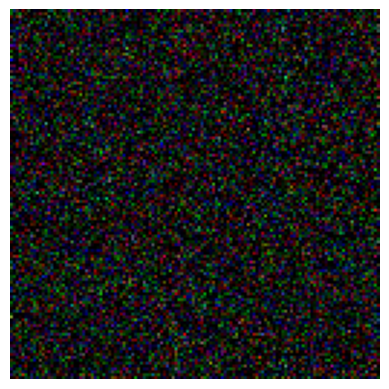

In [13]:
plt.imshow(dimmed_images[0,2])
plt.axis("off")
plt.show()

In [ ]:
# Initialization
d_in = 32
d_out = d_in * 4

vocab_size = 100
d_model = 2048

w1 = torch.randn(d_in,d_out) * ((2/(d_in + d_out)))**0.5
print(w1.shape, w1.mean(), w1.var())

embd = torch.randn(vocab_size, d_model)




In [ ]:
# Now I have to remember that if i want a given var i need to scale by the sqrt of that value

a = torch.randn(10000) * 10 # var( num * x) -> num^2 var(x)
a.var()

tensor(100.4098)

In [55]:
w1 = torch.empty(d_in, d_out)
std = (2 / (d_in + d_out))**0.5
torch.nn.init.trunc_normal_(
   w1,
   mean=0,
   std=std,
   a=-3 * std,
   b=3 * std
)

tensor([[ 0.0810,  0.0409,  0.1655,  ...,  0.0299, -0.0229,  0.0932],
        [-0.0630, -0.0334, -0.0156,  ..., -0.1860,  0.0108,  0.1918],
        [-0.0497, -0.2126, -0.0240,  ..., -0.0110, -0.0526,  0.0308],
        ...,
        [ 0.0574, -0.0198, -0.1234,  ...,  0.0103,  0.0402, -0.0655],
        [-0.1045, -0.0430,  0.1088,  ..., -0.0213, -0.1027,  0.0295],
        [-0.1167, -0.0820, -0.1047,  ...,  0.0460,  0.1173, -0.0560]])

In [38]:
def get_var(x):
   #To get the variance i firstly need to compute the mean
   mean = x.mean()

   summed_variance = 0
   for i in range(len(x)):
      summed_variance += (x[i] - mean)**2
   return summed_variance/(len(x) -1)

get_var(a), a.var()

   

(tensor(100.4099), tensor(100.4098))

In [60]:
vocab_size = 50
emb_dim = 500
batch_size = 10
sequence_length = 32
embedding_table = torch.randn(vocab_size,emb_dim)

token_ids = torch.randint(low = 0, high = vocab_size-1, size = (batch_size, sequence_length))
token_ids.shape

torch.Size([10, 32])

In [67]:
token_ids[0:2]

tensor([[48, 12, 41,  0, 22, 18, 15, 26, 21, 29, 20, 33,  9, 10, 42,  3, 47, 42,
         28,  9, 40, 12, 12, 34, 13, 36,  2, 29,  3, 48, 21, 22],
        [15, 19, 24, 36, 16,  0, 17, 10, 24, 43,  2, 32, 47, 25, 46, 45, 16, 33,
         40, 29, 24, 24, 15, 33, 48, 40,  7, 22, 43, 43, 22, 22]])

In [73]:
embedding_table[token_ids[0:2]].shape

torch.Size([2, 32, 500])